<a href="https://colab.research.google.com/github/AhmadObaidat/School/blob/main/Building%20and%20Evaluating%20a%20Supervised%20Machine%20Learning%20Classifier%20(End-to-End%20Workflow).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model A: StandardScaler + Logistic Regression (No PCA)
----------------------------------------------------------------------
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1-score : 0.9861
ROC AUC  : 0.9957
Confusion Matrix [ [TN FP] [FN TP] ]:
[[41  1]
 [ 1 71]]
Model B: StandardScaler + PCA(0.95 var, n=10) + Logistic Regression
----------------------------------------------------------------------
Accuracy : 0.9649
Precision: 0.9857
Recall   : 0.9583
F1-score : 0.9718
ROC AUC  : 0.9954
Confusion Matrix [ [TN FP] [FN TP] ]:
[[41  1]
 [ 3 69]]


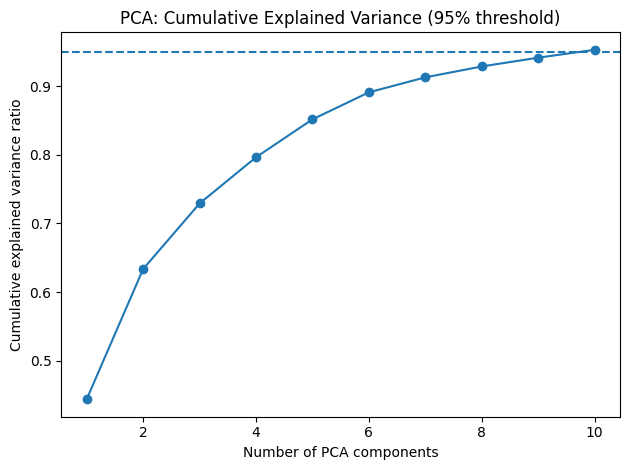

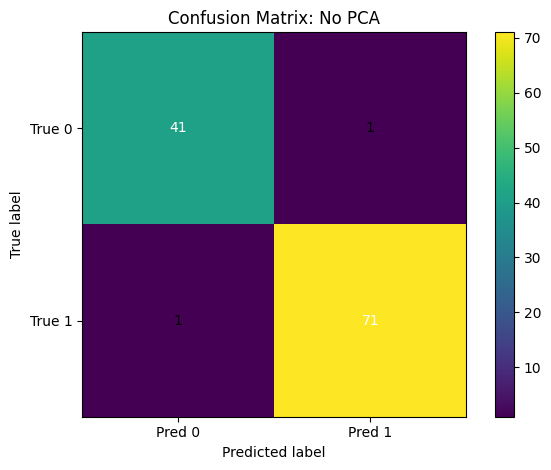

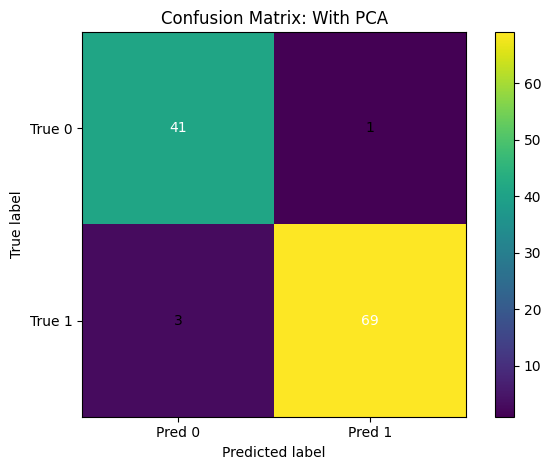

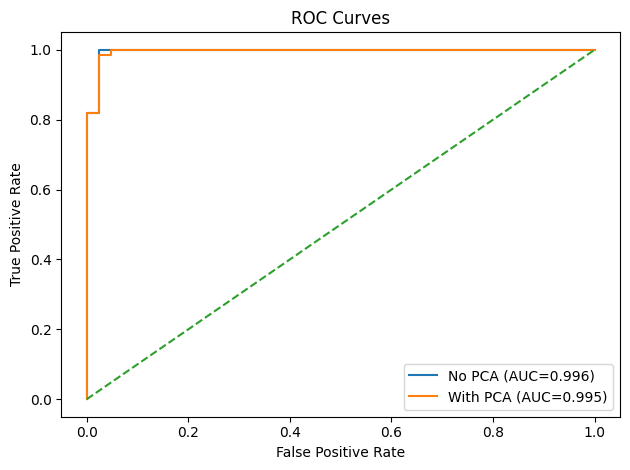

In [ ]:
# Building and Evaluating a Supervised ML Classifier
# Dataset: Breast Cancer Wisconsin (Diagnostic) from scikit-learn
# Workflow: Train/test split -> scaling -> (optional PCA) -> Logistic Regression -> multi-metric evaluation + visuals

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score
)

RANDOM_STATE = 42

# ----------------------------
# Part 1: Load dataset
# ----------------------------
X, y = load_breast_cancer(return_X_y=True)

# Split into train/test (stratify preserves class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# ----------------------------
# Part 2 & 3: Pipelines
#   A) Scaler + Logistic Regression
#   B) Scaler + PCA(95% variance) + Logistic Regression
# ----------------------------
pipe_no_pca = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, solver="liblinear", random_state=RANDOM_STATE))
])

pipe_with_pca = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(max_iter=5000, solver="liblinear", random_state=RANDOM_STATE))
])

# Fit both models
pipe_no_pca.fit(X_train, y_train)
pipe_with_pca.fit(X_train, y_train)

def evaluate_model(model, X_test, y_test):
    """Return predictions, probabilities, confusion matrix, and key metrics."""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # probability of positive class

    cm = confusion_matrix(y_test, y_pred)

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
    }

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    return y_pred, y_prob, cm, metrics, fpr, tpr

# Evaluate both
pred_no, prob_no, cm_no, met_no, fpr_no, tpr_no = evaluate_model(pipe_no_pca, X_test, y_test)
pred_pca, prob_pca, cm_pca, met_pca, fpr_pca, tpr_pca = evaluate_model(pipe_with_pca, X_test, y_test)

# Get PCA component count actually selected
n_comp = pipe_with_pca.named_steps["pca"].n_components_

# ----------------------------
# Part 4: Print metric summary
# ----------------------------
def print_report(title, met, cm):
    print("=" * 70)
    print(title)
    print("-" * 70)
    print(f"Accuracy : {met['accuracy']:.4f}")
    print(f"Precision: {met['precision']:.4f}")
    print(f"Recall   : {met['recall']:.4f}")
    print(f"F1-score : {met['f1']:.4f}")
    print(f"ROC AUC  : {met['roc_auc']:.4f}")
    print("Confusion Matrix [ [TN FP] [FN TP] ]:")
    print(cm)

print_report("Model A: StandardScaler + Logistic Regression (No PCA)", met_no, cm_no)
print_report(f"Model B: StandardScaler + PCA(0.95 var, n={n_comp}) + Logistic Regression", met_pca, cm_pca)

# ----------------------------
# Visualizations
#   1) PCA explained variance (only for the PCA pipeline)
#   2) Confusion matrices
#   3) ROC curves
# ----------------------------

# 1) PCA explained variance plot
pca = pipe_with_pca.named_steps["pca"]
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure()
plt.plot(range(1, len(cum_explained) + 1), cum_explained, marker="o")
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance ratio")
plt.title("PCA: Cumulative Explained Variance (95% threshold)")
plt.axhline(0.95, linestyle="--")
plt.tight_layout()
plt.show()

# 2) Confusion matrix heatmap-style (matplotlib only)
def plot_confusion_matrix(cm, title):
    plt.figure()
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ["Pred 0", "Pred 1"])
    plt.yticks(tick_marks, ["True 0", "True 1"])

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], "d"),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm_no, "Confusion Matrix: No PCA")
plot_confusion_matrix(cm_pca, "Confusion Matrix: With PCA")

# 3) ROC curves
plt.figure()
plt.plot(fpr_no, tpr_no, label=f"No PCA (AUC={met_no['roc_auc']:.3f})")
plt.plot(fpr_pca, tpr_pca, label=f"With PCA (AUC={met_pca['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Model A: StandardScaler + Logistic Regression (No PCA)
----------------------------------------------------------------------
Positive class: malignant
Accuracy : 0.9825
Precision: 0.9762
Recall   : 0.9762
F1-score : 0.9762
ROC AUC  : 0.9957
PR AUC   : 0.9944
Confusion Matrix (rows=true, cols=pred): [malignant, benign]
[[41  1]
 [ 1 71]]
Model B: StandardScaler + PCA(0.95 var, n=10) + Logistic Regression
----------------------------------------------------------------------
Positive class: malignant
Accuracy : 0.9649
Precision: 0.9318
Recall   : 0.9762
F1-score : 0.9535
ROC AUC  : 0.9954
PR AUC   : 0.9938
Confusion Matrix (rows=true, cols=pred): [malignant, benign]
[[41  1]
 [ 3 69]]


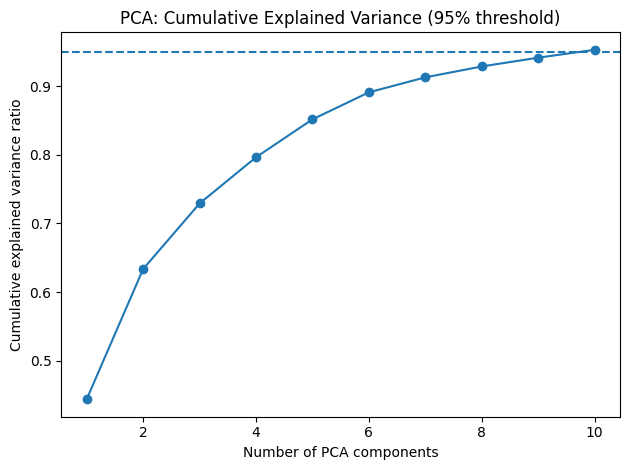

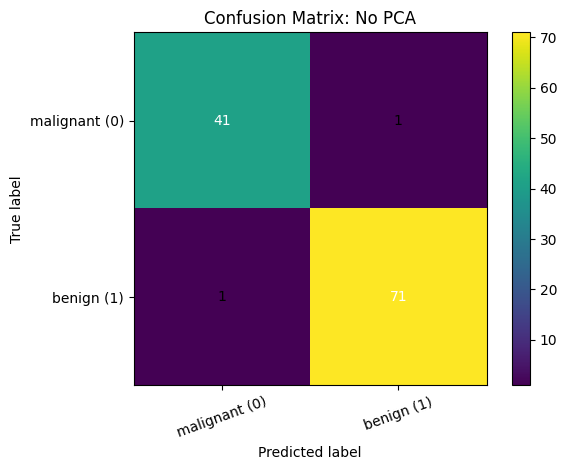

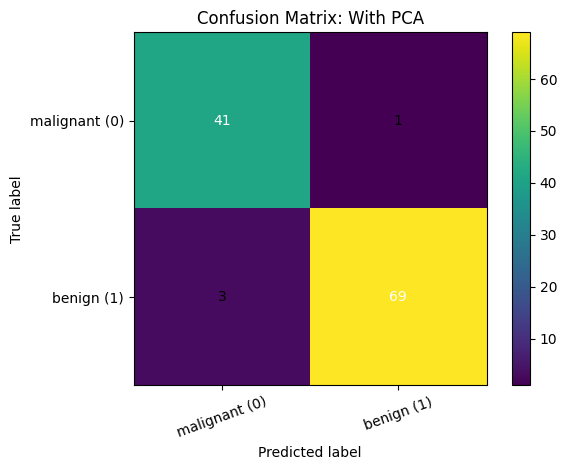

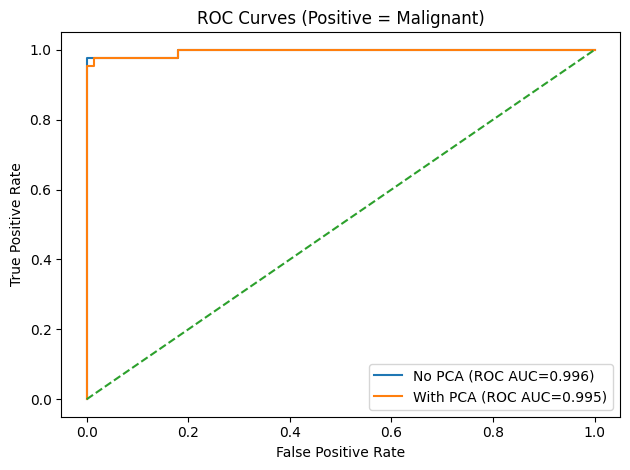

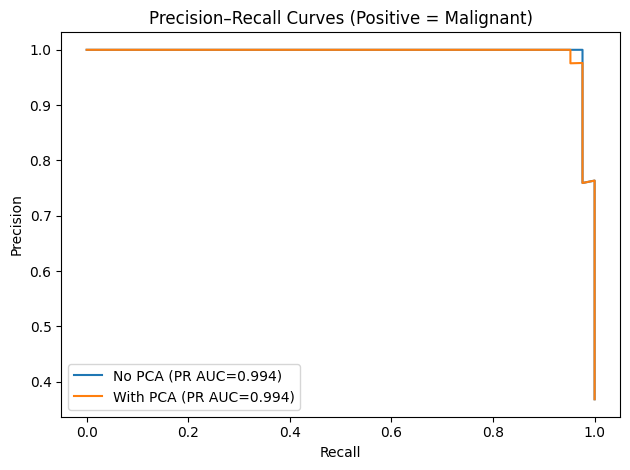

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

RANDOM_STATE = 42

# ----------------------------
# Part 1: Load dataset
# ----------------------------
data = load_breast_cancer()
X, y = data.data, data.target
class_names = data.target_names  # ['malignant', 'benign']

# IMPORTANT:
# In this dataset: 0 = malignant, 1 = benign
# We'll treat malignant as the "positive" class for evaluation by defining:
POS_LABEL = 0  # malignant

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# ----------------------------
# Part 2 & 3: Pipelines
# ----------------------------
pipe_no_pca = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, solver="liblinear"))
])

pipe_with_pca = Pipeline(steps=[
    ("scaler", StandardScaler()),
    # Deterministic PCA (reproducible) and keep 95% variance
    ("pca", PCA(n_components=0.95, svd_solver="full")),
    ("clf", LogisticRegression(max_iter=5000, solver="liblinear"))
])

pipe_no_pca.fit(X_train, y_train)
pipe_with_pca.fit(X_train, y_train)

def evaluate_model(model, X_test, y_test, pos_label=0):
    """
    Evaluate with malignant as the positive class.
    We compute:
      - Standard class predictions
      - Probabilities for the positive class (malignant)
      - Confusion matrix and key metrics
      - ROC and Precision–Recall curves
    """
    y_pred = model.predict(X_test)

    # predict_proba columns correspond to model.classes_
    # We want probability of malignant (class 0)
    proba = model.predict_proba(X_test)
    classes = model.named_steps["clf"].classes_
    pos_index = np.where(classes == pos_label)[0][0]
    y_score = proba[:, pos_index]

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label=pos_label),
        "recall": recall_score(y_test, y_pred, pos_label=pos_label),
        "f1": f1_score(y_test, y_pred, pos_label=pos_label),
        "roc_auc": roc_auc_score((y_test == pos_label).astype(int), y_score),
        "pr_auc": average_precision_score((y_test == pos_label).astype(int), y_score),
    }

    fpr, tpr, _ = roc_curve((y_test == pos_label).astype(int), y_score)
    prec, rec, _ = precision_recall_curve((y_test == pos_label).astype(int), y_score)

    return y_pred, y_score, cm, metrics, (fpr, tpr), (prec, rec)

pred_no, score_no, cm_no, met_no, roc_no, pr_no = evaluate_model(pipe_no_pca, X_test, y_test, POS_LABEL)
pred_pca, score_pca, cm_pca, met_pca, roc_pca, pr_pca = evaluate_model(pipe_with_pca, X_test, y_test, POS_LABEL)

n_comp = pipe_with_pca.named_steps["pca"].n_components_

def print_report(title, met, cm):
    print("=" * 70)
    print(title)
    print("-" * 70)
    print("Positive class:", class_names[POS_LABEL])
    print(f"Accuracy : {met['accuracy']:.4f}")
    print(f"Precision: {met['precision']:.4f}")
    print(f"Recall   : {met['recall']:.4f}")
    print(f"F1-score : {met['f1']:.4f}")
    print(f"ROC AUC  : {met['roc_auc']:.4f}")
    print(f"PR AUC   : {met['pr_auc']:.4f}")
    print("Confusion Matrix (rows=true, cols=pred): [malignant, benign]")
    print(cm)

print_report("Model A: StandardScaler + Logistic Regression (No PCA)", met_no, cm_no)
print_report(f"Model B: StandardScaler + PCA(0.95 var, n={n_comp}) + Logistic Regression", met_pca, cm_pca)

# ----------------------------
# Visualizations
# ----------------------------

# 1) PCA explained variance plot
pca = pipe_with_pca.named_steps["pca"]
cum_explained = np.cumsum(pca.explained_variance_ratio_)

plt.figure()
plt.plot(range(1, len(cum_explained) + 1), cum_explained, marker="o")
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance ratio")
plt.title("PCA: Cumulative Explained Variance (95% threshold)")
plt.axhline(0.95, linestyle="--")
plt.tight_layout()
plt.show()

# 2) Confusion matrix plot (labeled)
def plot_confusion_matrix(cm, title):
    plt.figure()
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    labels = ["malignant (0)", "benign (1)"]
    plt.xticks([0, 1], labels, rotation=20)
    plt.yticks([0, 1], labels)

    thresh = cm.max() / 2.0
    for i in range(2):
        for j in range(2):
            plt.text(j, i, format(cm[i, j], "d"),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm_no, "Confusion Matrix: No PCA")
plot_confusion_matrix(cm_pca, "Confusion Matrix: With PCA")

# 3) ROC curves (malignant as positive)
plt.figure()
plt.plot(roc_no[0], roc_no[1], label=f"No PCA (ROC AUC={met_no['roc_auc']:.3f})")
plt.plot(roc_pca[0], roc_pca[1], label=f"With PCA (ROC AUC={met_pca['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Positive = Malignant)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 4) Precision–Recall curves
plt.figure()
plt.plot(pr_no[1], pr_no[0], label=f"No PCA (PR AUC={met_no['pr_auc']:.3f})")
plt.plot(pr_pca[1], pr_pca[0], label=f"With PCA (PR AUC={met_pca['pr_auc']:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves (Positive = Malignant)")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()